In [4]:
url = "../../data/raw/PetImages/Dog/0.jpg"

In [5]:
from transformers import SamModel, SamProcessor
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"
model = SamModel.from_pretrained("facebook/sam-vit-base").to(device)
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

# Define a point prompt [x, y] - where you think the object is
input_points = [[[450, 600]]] 

# Process image and prompt
inputs = processor(url, input_points=input_points, return_tensors="pt")
for k, v in inputs.items():
    if "size" in k:
        inputs[k] = v.to(device) # Keep as int64/long
    else:
        inputs[k] = v.to(torch.float32).to(device) # Move to float32 for MPS

# Predict mask
with torch.no_grad():
    outputs = model(**inputs)

# Convert output to a usable mask
masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu()
)

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

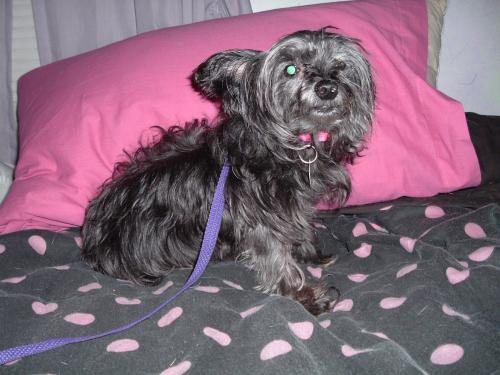

In [6]:
import numpy as np
from PIL import Image, ImageOps, ImageChops

# Assuming your image is already loaded from image_path = "cats.jpg"
original_image = Image.open(url).convert("RGB")
draw_mask = masks[0][0][0] # Get the very first [1, H, W] mask tensor

# Convert to 1D boolean array for visualization
# Note: post_process_masks usually handles [H, W] resizing for you
mask_bool = draw_mask.detach().cpu().numpy()

original_image

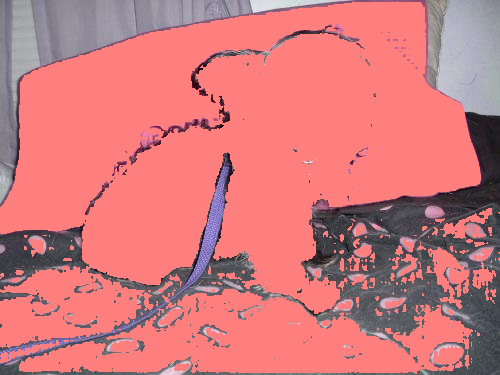

In [7]:
# 1. Create a semi-transparent colored overlay the same size as the image
# (e.g., Red with 50% opacity)
color = (255, 0, 0) # Red
alpha = 128         # ~50% opacity (0-255)
overlay_color = Image.new("RGBA", original_image.size, color + (alpha,))

# 2. Create an exact mask for the shape
# Convert the boolean mask (False/True) to grayscale PIL (0/255)
# This acts as an alpha channel to define *where* the overlay is shown
mask_image = Image.fromarray((mask_bool * 255).astype(np.uint8)).convert("L")

# 3. Create a composite image combining original + overlay
# This puts the overlay_color onto the original_image, but only where mask_image is white
overlay_image = Image.composite(overlay_color, original_image.convert("RGBA"), mask_image)

overlay_image

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'score': 0.9975630044937134, 'label': 'bed', 'box': {'xmin': 0, 'ymin': 0, 'xmax': 499, 'ymax': 374}}, {'score': 0.9997923970222473, 'label': 'dog', 'box': {'xmin': 79, 'ymin': 26, 'xmax': 375, 'ymax': 314}}]
[{'score': 0.9975630044937134, 'label': 'bed', 'box': {'xmin': 0, 'ymin': 0, 'xmax': 499, 'ymax': 374}}, {'score': 0.9997923970222473, 'label': 'dog', 'box': {'xmin': 79, 'ymin': 26, 'xmax': 375, 'ymax': 314}}]
[{'score': 0.9975630044937134, 'label': 'bed', 'box': {'xmin': 0, 'ymin': 0, 'xmax': 499, 'ymax': 374}}, {'score': 0.9997923970222473, 'label': 'dog', 'box': {'xmin': 79, 'ymin': 26, 'xmax': 375, 'ymax': 314}}]


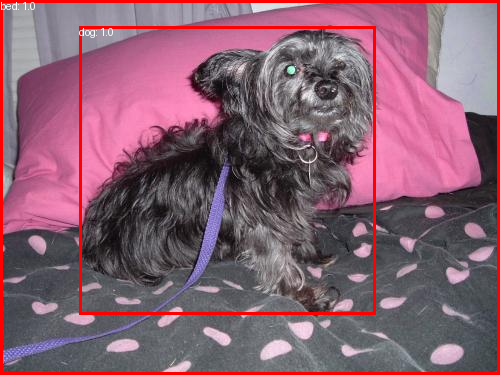

In [8]:
from transformers import pipeline
from PIL import Image, ImageDraw

# 1. Load an object detection pipeline (Transformer-based)
# This model uses a ResNet-50 backbone + Transformer encoder/decoder
detector = pipeline("object-detection", model="facebook/detr-resnet-50")

# 2. Run detection on an image
image_path = url
results = detector(image_path)

# 3. Draw the bounding boxes
image = Image.open(image_path)
draw = ImageDraw.Draw(image)

print(results)

for prediction in results:
    print(results)
    box = prediction["box"]
    label = prediction["label"]
    score = round(prediction["score"], 2)
    
    # Extract coordinates
    xmin, ymin, xmax, ymax = box["xmin"], box["ymin"], box["xmax"], box["ymax"]
    
    # Draw the rectangle and text
    draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)
    draw.text((xmin, ymin), f"{label}: {score}", fill="white")

image